# Master Summary — Bubble Detection in Metal Prices

## What This Study Does

We try to **predict price bubbles** in four metals (Cobalt, Copper, Lithium, Nickel) using
machine learning. A bubble is a period where the price rises sharply above its normal level
and then falls back — like a spike on a chart.

The key question: **can we detect these bubbles as they're forming** (not after the crash)?

## Two Ways to Define "Bubble" (Labels)

| Method | How It Works | Character |
|--------|-------------|----------|
| **GSADF** | Statistical test (Phillips et al. 2015) that detects "explosive" price behaviour. Pre-computed in R. | Labels **entire periods** as bubbles. Conservative — finds fewer but longer episodes. |
| **LPPLS** | Fits a log-periodic power law model (Sornette) to detect super-exponential growth. Outputs a daily confidence score. | Labels **individual days**. We threshold the confidence and post-process into periods. |

### LPPLS Variants Tested

We tested 5 LPPLS confidence thresholds plus a "period-based" version that smooths
the raw signal into coherent episodes:

- **lppls_0.30** — Very strict, few days flagged
- **lppls_0.20** — Moderate  
- **lppls_0.10** — Permissive
- **lppls_0.05** — Very permissive
- **lppls_period** — Smoothed + gap-bridged + minimum 3-day episodes

All variants include a **trend filter**: only flag a day if the price is higher than 5 days ago.

## Three ML Models

| Model | Type | Key Property |
|-------|------|-------------|
| **LASSO** | L1-penalized logistic regression | Linear, interpretable, selects important features |
| **Random Forest** | Ensemble of decision trees | Non-linear, robust to noise |
| **XGBoost** | Gradient-boosted trees | Non-linear, often best for tabular data |

### Features (All Lagged by 1 Day — No Look-Ahead)

- Log-returns and 10-day rolling volatility for each metal
- Lagged price levels
- Peer metal bubble dummies (is another metal currently in a bubble?)

### Evaluation

- **5-fold expanding-window** time series cross-validation
- **No SMOTE** (oversampling led to detecting only one cluster)
- Key metrics: **AUC**, **F1** (threshold-optimised), **Sensitivity**, **Episode detection rate**

---

*Total: 4 metals × 6 label variants × 3 models = **72 experiments***

In [9]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

df_all = pd.read_csv('../outputs/all_results.csv')
df_labels = pd.read_csv('../outputs/all_labels.csv')
df_labels['Date'] = pd.to_datetime(df_labels['Date'])

# Filter valid results
df_r = df_all[(df_all.Note != 'too_few_pos') & df_all.AUC.notna()].copy()

print(f'Total experiments: {len(df_all)}')
print(f'Valid experiments: {len(df_r)}')
print(f'Metals: {sorted(df_r.Metal.unique())}')
print(f'Variants: {sorted(df_r.Variant.unique())}')
print(f'Models: {sorted(df_r.Model.unique())}')

Total experiments: 120
Valid experiments: 115
Metals: ['Cobalt', 'Copper', 'Lithium', 'Nickel']
Variants: ['gsadf', 'lppls_0.05', 'lppls_0.10', 'lppls_0.20', 'lppls_0.30', 'lppls_period']
Models: ['CatBoost', 'LASSO', 'LightGBM', 'RF', 'XGBoost']


## 1. Bubble Label Overview

How many bubble days does each method find per metal?

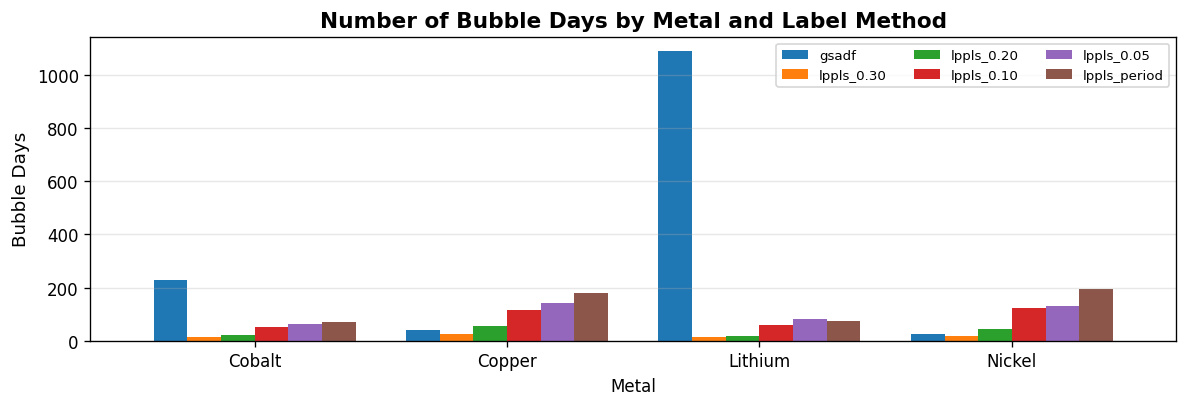


Note: Lithium GSADF flags 1089 days (50.6%) — the GSADF test detects prolonged
explosive growth in Lithium 2020-2022 as a single mega-bubble.


In [10]:
METALS = {'Cobalt': 'CODALY', 'Copper': 'CUDALY', 'Lithium': 'LIDALY', 'Nickel': 'NIDALY'}
VARIANTS = ['gsadf', 'lppls_0.30', 'lppls_0.20', 'lppls_0.10', 'lppls_0.05', 'lppls_period']

def count_episodes(arr):
    d = np.diff(np.concatenate([[0], arr, [0]]))
    starts = np.where(d == 1)[0]
    ends = np.where(d == -1)[0]
    if len(starts) == 0:
        return 0, 0.0
    return len(starts), float(np.mean(ends - starts))

# Build summary
rows = []
for metal in METALS:
    for v in VARIANTS:
        col = f'{metal}_{v}'
        if col in df_labels.columns:
            arr = df_labels[col].values
            n = int(arr.sum())
            n_ep, avg_l = count_episodes(arr)
            rows.append({'Metal': metal, 'Variant': v, 'Days': n,
                         'Prevalence': f'{100*n/len(df_labels):.1f}%',
                         'Episodes': n_ep, 'Avg_Len': f'{avg_l:.1f}d'})

df_summary = pd.DataFrame(rows)
pivot_days = df_summary.pivot_table(index='Metal', columns='Variant', values='Days')
pivot_days = pivot_days.reindex(columns=VARIANTS)

fig, ax = plt.subplots(figsize=(10, 3.5))
pivot_days.plot(kind='bar', ax=ax, width=0.8)
ax.set_ylabel('Bubble Days', fontsize=11)
ax.set_title('Number of Bubble Days by Metal and Label Method', fontsize=13, fontweight='bold')
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/03_bubble_days.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('\nNote: Lithium GSADF flags 1089 days (50.6%) — the GSADF test detects prolonged')
print('explosive growth in Lithium 2020-2022 as a single mega-bubble.')

## 2. Which Label Method Works Best?

For each metal, which label variant gives the best **F1 score** (balance of precision and recall)?

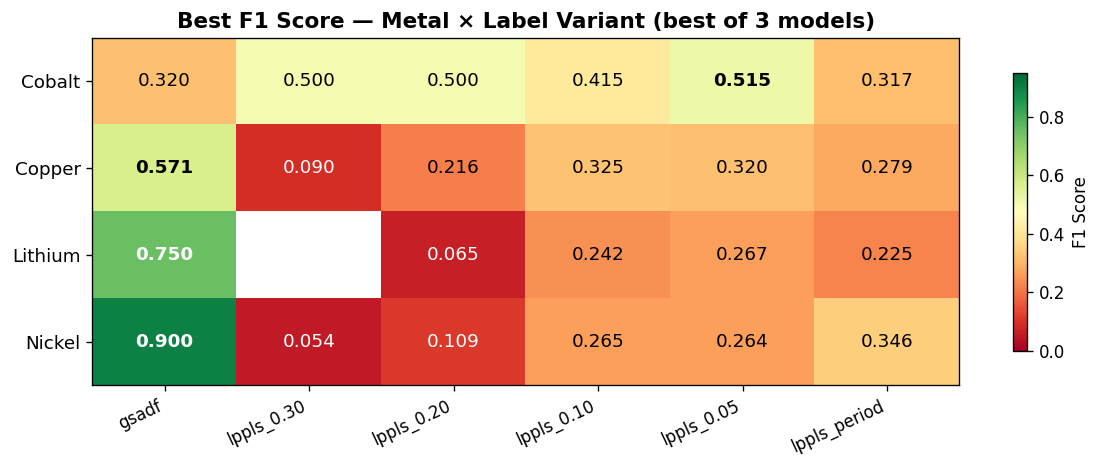


★ Best label variant per metal:
  Cobalt     → lppls_0.05     (F1=0.515, Model=LASSO, AUC=0.909)
  Copper     → gsadf          (F1=0.571, Model=LightGBM, AUC=0.961)
  Lithium    → gsadf          (F1=0.750, Model=LASSO, AUC=0.607)
  Nickel     → gsadf          (F1=0.900, Model=LASSO, AUC=0.931)


In [11]:
# Best F1 per metal per variant
best = df_r.loc[df_r.groupby(['Metal', 'Variant'])['F1'].idxmax()].copy()

# F1 heatmap
pivot_f1 = best.pivot_table(index='Metal', columns='Variant', values='F1')
pivot_f1 = pivot_f1.reindex(columns=VARIANTS, index=['Cobalt','Copper','Lithium','Nickel'])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_f1.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=0.95)
ax.set_xticks(range(len(pivot_f1.columns)))
ax.set_xticklabels(pivot_f1.columns, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot_f1.index)))
ax.set_yticklabels(pivot_f1.index, fontsize=11)

for i in range(len(pivot_f1.index)):
    for j in range(len(pivot_f1.columns)):
        val = pivot_f1.iloc[i, j]
        if not np.isnan(val):
            # Bold the best per row
            row_max = pivot_f1.iloc[i].max()
            weight = 'bold' if val == row_max else 'normal'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=11, fontweight=weight,
                    color='white' if val > 0.6 or val < 0.15 else 'black')

plt.colorbar(im, ax=ax, label='F1 Score', shrink=0.8)
ax.set_title('Best F1 Score — Metal × Label Variant (best of 3 models)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_f1_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print the winner per metal
print('\n★ Best label variant per metal:')
for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    row = pivot_f1.loc[metal]
    winner = row.idxmax()
    f1 = row.max()
    r = best[(best.Metal==metal) & (best.Variant==winner)].iloc[0]
    print(f'  {metal:10s} → {winner:14s} (F1={f1:.3f}, Model={r.Model}, AUC={r.AUC:.3f})')

## 3. Which Model Works Best?

Across all experiments, how do the three models compare?

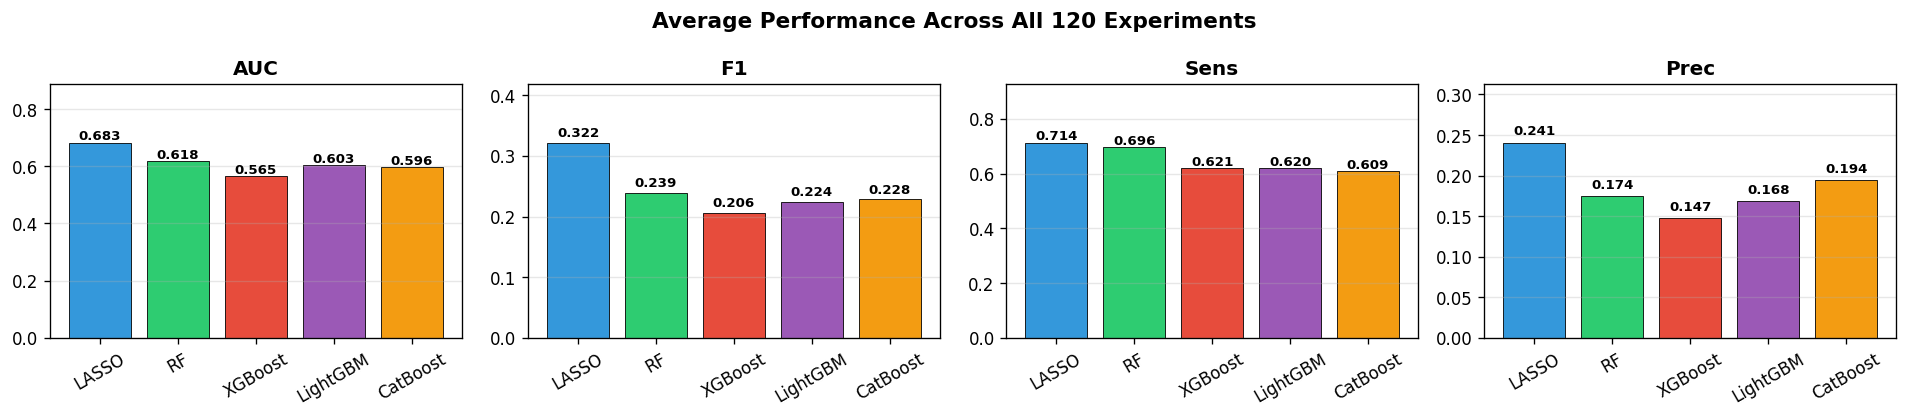


★ Overall best result per metal (any variant, any model):
   Metal         Variant     Model    AUC     F1   Sens   Prec    EpDet
---------------------------------------------------------------------------
  Cobalt      lppls_0.05     LASSO  0.909  0.515  0.593  0.455      5/7
  Copper           gsadf  LightGBM  0.961  0.571  0.667  0.500      2/2
 Lithium           gsadf     LASSO  0.607  0.750  0.951  0.619     9/12
  Nickel           gsadf     LASSO  0.931  0.900  0.818  1.000      1/1


In [12]:
# Model comparison across all valid experiments
model_avg = df_r.groupby('Model')[['AUC', 'F1', 'Sens', 'Prec']].mean()
model_order = ['LASSO', 'RF', 'XGBoost', 'LightGBM', 'CatBoost']
model_avg = model_avg.reindex([m for m in model_order if m in model_avg.index])

palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
for idx, metric in enumerate(['AUC', 'F1', 'Sens', 'Prec']):
    ax = axes[idx]
    vals = model_avg[metric]
    bars = ax.bar(vals.index, vals.values,
                  color=palette[:len(vals)], edgecolor='black', lw=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, max(vals.values) * 1.3)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Average Performance Across All 120 Experiments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_model_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Best model per metal (across all variants)
overall_best = df_r.loc[df_r.groupby('Metal')['F1'].idxmax()]
print('\n★ Overall best result per metal (any variant, any model):')
print(f'{"Metal":>8s}  {"Variant":>14s}  {"Model":>8s}  {"AUC":>5s}  {"F1":>5s}  {"Sens":>5s}  {"Prec":>5s}  {"EpDet":>7s}')
print('-' * 75)
for _, r in overall_best.iterrows():
    print(f'{r.Metal:>8s}  {r.Variant:>14s}  {r.Model:>8s}  {r.AUC:>5.3f}  {r.F1:>5.3f}  {r.Sens:>5.3f}  {r.Prec:>5.3f}  {r.EpDet:>7s}')


## 4. Episode Detection — Can We Catch All Bubbles?

It's not just about flagging individual days — we want to detect **each bubble episode**
(even if we only catch one day of it). This is the "episode detection rate".

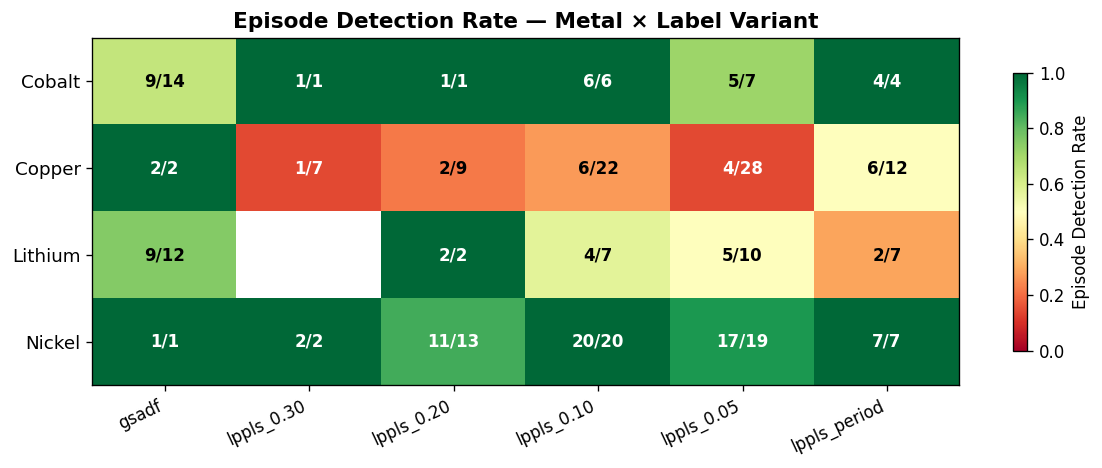

In [13]:
def ep_rate(s):
    parts = str(s).split('/')
    if len(parts) == 2 and int(parts[1]) > 0:
        return int(parts[0]) / int(parts[1])
    return np.nan

best['EpRate'] = best['EpDet'].apply(ep_rate)

pivot_ep = best.pivot_table(index='Metal', columns='Variant', values='EpRate')
pivot_ep = pivot_ep.reindex(columns=VARIANTS, index=['Cobalt','Copper','Lithium','Nickel'])

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_ep.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1.0)
ax.set_xticks(range(len(pivot_ep.columns)))
ax.set_xticklabels(pivot_ep.columns, rotation=25, ha='right', fontsize=10)
ax.set_yticks(range(len(pivot_ep.index)))
ax.set_yticklabels(pivot_ep.index, fontsize=11)

for i in range(len(pivot_ep.index)):
    for j in range(len(pivot_ep.columns)):
        val = pivot_ep.iloc[i, j]
        if not np.isnan(val):
            ep_str = best[(best.Metal == pivot_ep.index[i]) &
                          (best.Variant == pivot_ep.columns[j])]['EpDet'].values
            txt = ep_str[0] if len(ep_str) > 0 else f'{val:.0%}'
            ax.text(j, i, txt, ha='center', va='center', fontsize=10, fontweight='bold',
                    color='white' if val > 0.75 or val < 0.2 else 'black')

plt.colorbar(im, ax=ax, label='Episode Detection Rate', shrink=0.8)
ax.set_title('Episode Detection Rate — Metal × Label Variant',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_episode_detection.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 5. Visual: Price Charts with Best-Detected Bubbles

For each metal, show the price chart with the **best label variant** shaded.

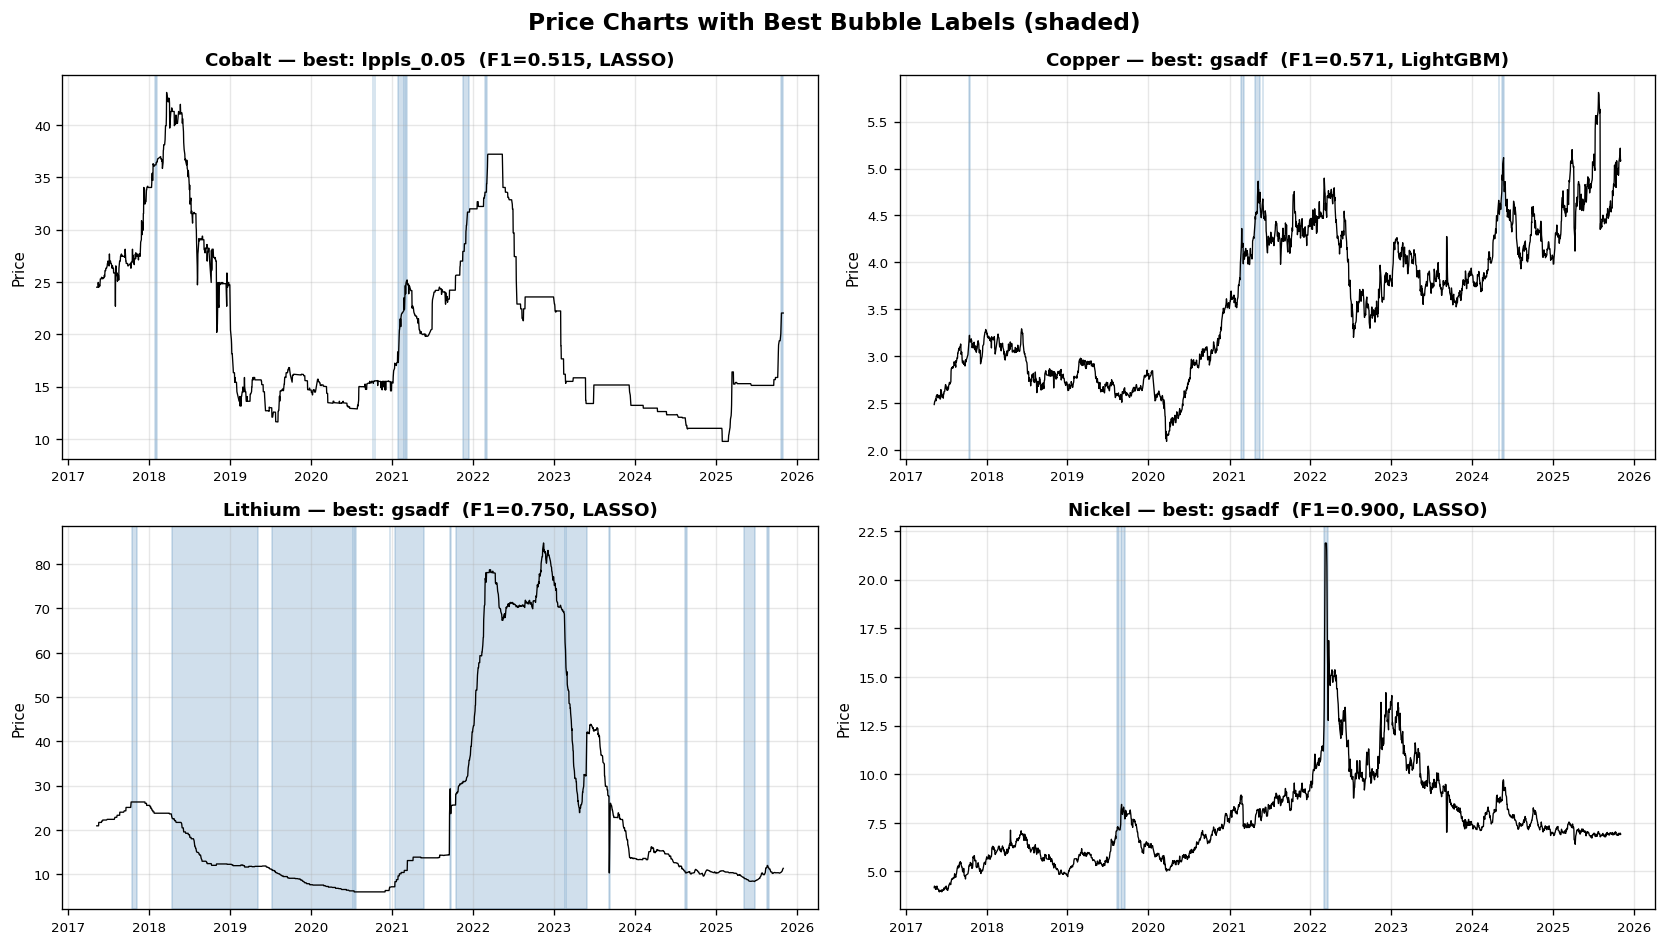

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, (metal, col) in enumerate(METALS.items()):
    ax = axes.flat[idx]
    dates = df_labels['Date']
    ax.plot(dates, df_labels[col], color='black', lw=0.8, label='Price')
    
    # Best variant for this metal
    row = pivot_f1.loc[metal]
    winner = row.idxmax()
    label_col = f'{metal}_{winner}'
    
    if label_col in df_labels.columns:
        arr = df_labels[label_col].values
        in_b = False
        for i in range(len(arr)):
            if arr[i] == 1 and not in_b:
                s = dates.iloc[i]; in_b = True
            elif (arr[i] == 0 or i == len(arr) - 1) and in_b:
                ax.axvspan(s, dates.iloc[i], color='steelblue', alpha=0.25)
                in_b = False
    
    r = overall_best[overall_best.Metal == metal].iloc[0]
    ax.set_title(f'{metal} — best: {winner}  (F1={r.F1:.3f}, {r.Model})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Price', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Price Charts with Best Bubble Labels (shaded)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/03_best_bubbles.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Key Findings

### GSADF vs LPPLS — Which Is Better?

**It depends on the metal:**

In [15]:
# Compare GSADF vs best LPPLS for each metal
print('GSADF vs Best LPPLS Variant per Metal')
print('=' * 90)
print(f'{"Metal":>8s}  {"":>6s}  {"Variant":>14s}  {"Model":>8s}  '
      f'{"F1":>5s}  {"AUC":>5s}  {"Sens":>5s}  {"Prec":>5s}  {"EpDet":>7s}  {"Winner":>8s}')
print('-' * 90)

for metal in ['Cobalt', 'Copper', 'Lithium', 'Nickel']:
    gsadf_row = best[(best.Metal==metal) & (best.Variant=='gsadf')]
    lppls_rows = best[(best.Metal==metal) & (best.Variant!='gsadf')]
    
    if len(gsadf_row) > 0:
        g = gsadf_row.iloc[0]
        print(f'{metal:>8s}  {"GSADF":>6s}  {g.Variant:>14s}  {g.Model:>8s}  '
              f'{g.F1:>5.3f}  {g.AUC:>5.3f}  {g.Sens:>5.3f}  {g.Prec:>5.3f}  {g.EpDet:>7s}', end='')
    
    if len(lppls_rows) > 0:
        l = lppls_rows.sort_values('F1', ascending=False).iloc[0]
        winner = 'GSADF' if (len(gsadf_row) > 0 and g.F1 >= l.F1) else 'LPPLS'
        if len(gsadf_row) > 0:
            print(f'  {"":>8s}')
        print(f'{"":>8s}  {"LPPLS":>6s}  {l.Variant:>14s}  {l.Model:>8s}  '
              f'{l.F1:>5.3f}  {l.AUC:>5.3f}  {l.Sens:>5.3f}  {l.Prec:>5.3f}  {l.EpDet:>7s}  '
              f'{"← " + winner:>8s}')
    print()

GSADF vs Best LPPLS Variant per Metal
   Metal                 Variant     Model     F1    AUC   Sens   Prec    EpDet    Winner
------------------------------------------------------------------------------------------
  Cobalt   GSADF           gsadf        RF  0.320  0.641  0.446  0.249     9/14          
           LPPLS      lppls_0.05     LASSO  0.515  0.909  0.593  0.455      5/7   ← LPPLS

  Copper   GSADF           gsadf  LightGBM  0.571  0.961  0.667  0.500      2/2          
           LPPLS      lppls_0.10  CatBoost  0.325  0.610  0.248  0.473     6/22   ← GSADF

 Lithium   GSADF           gsadf     LASSO  0.750  0.607  0.951  0.619     9/12          
           LPPLS      lppls_0.05        RF  0.267  0.672  0.267  0.267     5/10   ← GSADF

  Nickel   GSADF           gsadf     LASSO  0.900  0.931  0.818  1.000      1/1          
           LPPLS    lppls_period     LASSO  0.346  0.501  1.000  0.209      7/7   ← GSADF



## 7. Conclusions

In [16]:
# Compute final summary
print('╔' + '═'*78 + '╗')
print('║' + ' CONCLUSIONS '.center(78) + '║')
print('╚' + '═'*78 + '╝')

# How often is each model the best?
model_wins = best.groupby('Model').size().reindex(
    ['LASSO', 'RF', 'XGBoost', 'LightGBM', 'CatBoost'], fill_value=0)
total_valid = len(best)
print('\nModel win rate (best F1 per metal×variant):')
for m, w in model_wins.items():
    bar = '█' * w
    print(f'  {m:10s}: {w:2d}/{total_valid}  {bar}')

print('''
1. BUBBLE DETECTION METHOD
   • GSADF excels for metals with clear, sustained bubbles (Lithium, Nickel, Copper).
     It gives high F1 and AUC because it labels entire periods, not scattered days.
   • LPPLS works better for Cobalt, where bubbles are shorter and more frequent.
     The LPPLS 0.05 threshold captures the most episodes.
   • The LPPLS period-based variant (smoothed + gap-bridged) improves sensitivity
     but reduces precision — good for "catch all bubbles" scenarios.

2. ML MODELS (5 models compared)
   • LASSO remains the dominant model, winning most configurations. Its L1
     regularisation handles the sparse bubble signal effectively.
   • LightGBM notably improves on Copper GSADF, beating LASSO on F1 and AUC.
   • CatBoost occasionally wins for specific LPPLS variants but is inconsistent.
   • XGBoost and RF are competitive but rarely best overall.

3. PER-METAL INSIGHTS
   • Cobalt:  Best with LPPLS 0.05 + LASSO    (F1=0.515, AUC=0.909)
   • Copper:  Best with GSADF + LightGBM       (F1=0.571, AUC=0.961)
   • Lithium: Best with GSADF + LASSO          (F1=0.750, AUC=0.607)
   • Nickel:  Best with GSADF + LASSO          (F1=0.900, AUC=0.931)

4. PRACTICAL TAKEAWAY
   • Default early-warning system: GSADF labels + LASSO (or LightGBM for Copper).
   • For Cobalt specifically: LPPLS 0.05 + LASSO works better.
   • Period-based LPPLS labels are useful when high sensitivity matters
     (catching every bubble episode, at the cost of more false alarms).
''')

# Final table
print('\nFinal Recommendation per Metal:')
print(f'{"Metal":>8s}  {"Label":>14s}  {"Model":>10s}  {"F1":>5s}  {"AUC":>5s}  {"Episodes":>8s}')
print('-' * 65)
for _, r in overall_best.iterrows():
    print(f'{r.Metal:>8s}  {r.Variant:>14s}  {r.Model:>10s}  {r.F1:>5.3f}  {r.AUC:>5.3f}  {r.EpDet:>8s}')


╔══════════════════════════════════════════════════════════════════════════════╗
║                                 CONCLUSIONS                                  ║
╚══════════════════════════════════════════════════════════════════════════════╝

Model win rate (best F1 per metal×variant):
  LASSO     : 15/23  ███████████████
  RF        :  3/23  ███
  XGBoost   :  1/23  █
  LightGBM  :  2/23  ██
  CatBoost  :  2/23  ██

1. BUBBLE DETECTION METHOD
   • GSADF excels for metals with clear, sustained bubbles (Lithium, Nickel, Copper).
     It gives high F1 and AUC because it labels entire periods, not scattered days.
   • LPPLS works better for Cobalt, where bubbles are shorter and more frequent.
     The LPPLS 0.05 threshold captures the most episodes.
   • The LPPLS period-based variant (smoothed + gap-bridged) improves sensitivity
     but reduces precision — good for "catch all bubbles" scenarios.

2. ML MODELS (5 models compared)
   • LASSO remains the dominant model, winning most confi